<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial_04/Tutorial04_DataAugmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 1: The PyTorch Augmentation Task**

In [2]:
import os
import torch
from PIL import Image
from torchvision import transforms
import numpy as np

# 1. Setup Directory
output_dir = "augmented_images"
os.makedirs(output_dir, exist_ok=True)

# 2. Load the image
img_path = 'beautiful-tropical-colorful-bird.jpg'
try:
    original_img = Image.open(img_path).convert('RGB')
    print(f"Successfully loaded {img_path}")
except FileNotFoundError:
    print(f"Error: {img_path} not found. Please upload the file to Colab.")
    raise

# 3. Define the Augmentation Pipeline
# Mapping Keras parameters to PyTorch equivalents:
# rotation_range=40 -> RandomRotation(40)
# width/height_shift_range=0.2 -> translate=(0.2, 0.2) in RandomAffine
# shear_range=0.2 -> shear=0.2 in RandomAffine
# zoom_range=0.2 -> scale=(0.8, 1.2) in RandomAffine
# horizontal_flip=True -> RandomHorizontalFlip()
augmentation_pipeline = transforms.Compose([
    transforms.RandomRotation(degrees=40),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),
        shear=0.2,
        scale=(0.8, 1.2)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(), # Required to convert to tensor for saving/processing
    transforms.ToPILImage() # Convert back to PIL image to save as JPEG
])

# 4. Generate and Save 40 Distinct Images
num_augmented_images = 40
print(f"Generating {num_augmented_images} images...")

for i in range(num_augmented_images):
    # Apply the pipeline
    augmented_img = augmentation_pipeline(original_img)

    # Save with unique filename
    file_name = f"aug_bird_{i+1:02d}.jpg"
    save_path = os.path.join(output_dir, file_name)
    augmented_img.save(save_path, "JPEG")

print(f"Done! 40 images saved in folder: '{os.path.abspath(output_dir)}'")

Successfully loaded beautiful-tropical-colorful-bird.jpg
Generating 40 images...
Done! 40 images saved in folder: '/content/augmented_images'


# **Phase 2: Generating the Grid for the Report**

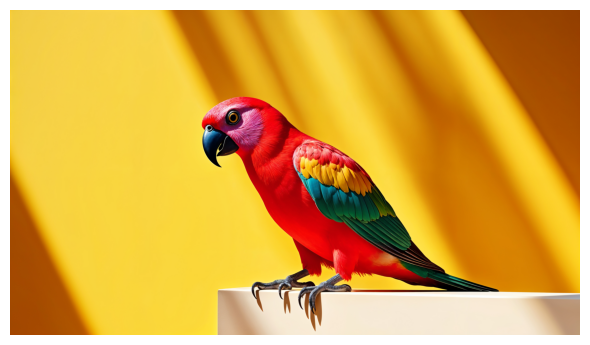

Saved: fig1_original.png


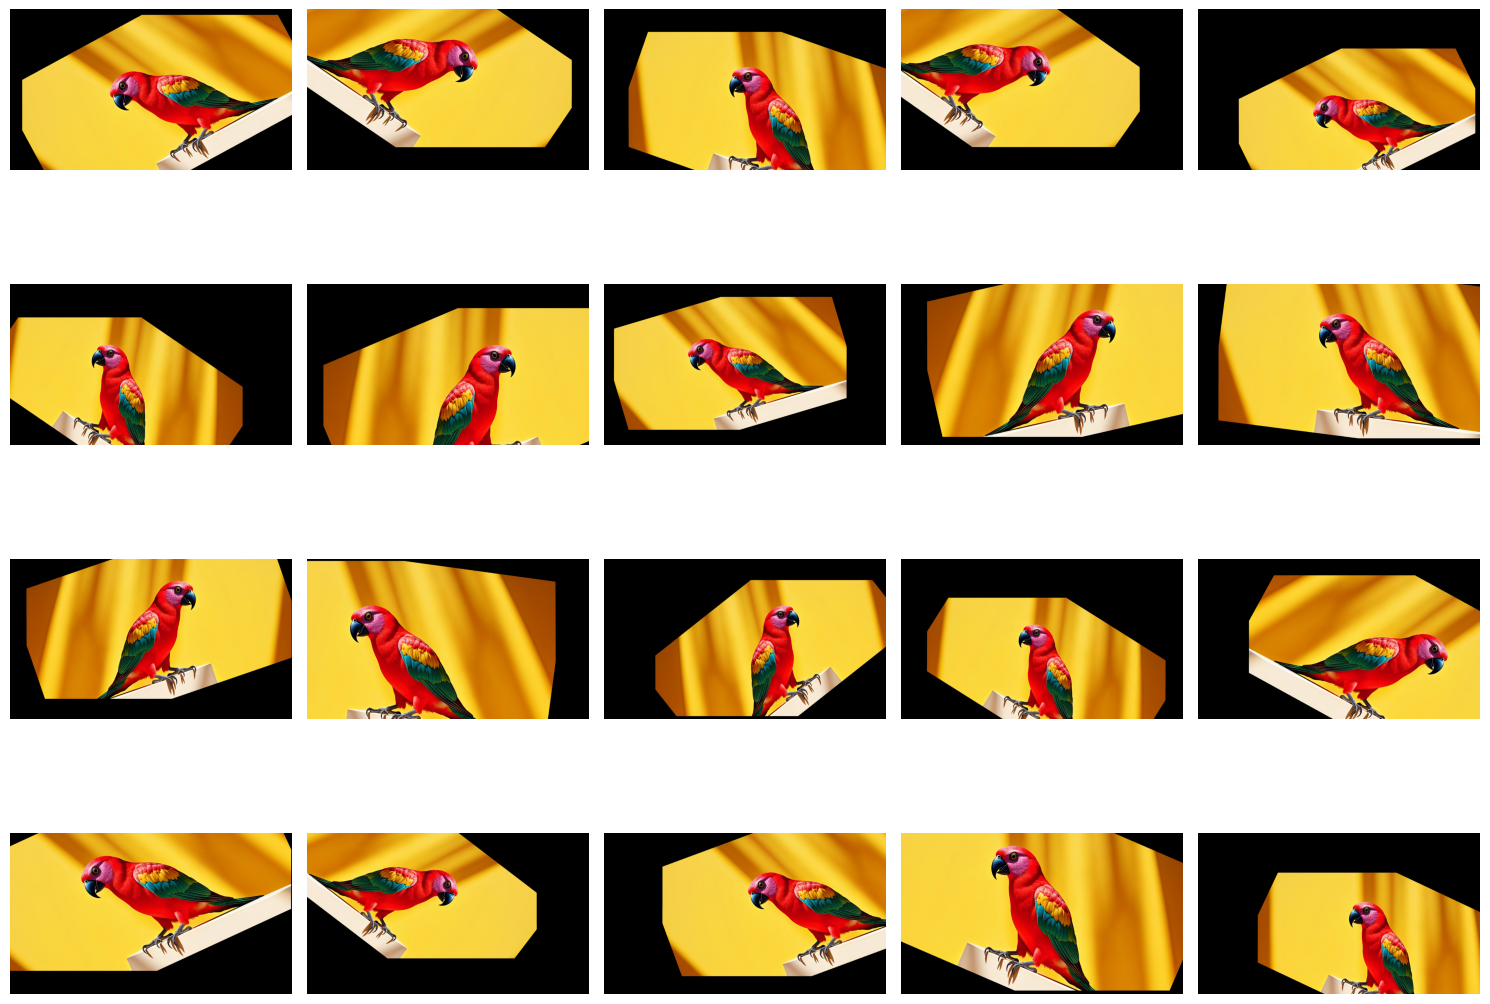

Saved: fig2_augmented_grid.png


In [3]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# 1. Setup paths
img_path = 'beautiful-tropical-colorful-bird.jpg'
aug_dir = 'augmented_images'

# 2. Generate Figure 1: Original Image
plt.figure(figsize=(6, 6))
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')  # No axes
plt.tight_layout()
plt.savefig('fig1_original.png', bbox_inches='tight', pad_inches=0)
plt.show()
print("Saved: fig1_original.png")

# 3. Generate Figure 2: Augmented Grid (4x5)
# Get list of all augmented images
all_aug_files = [f for f in os.listdir(aug_dir) if f.endswith('.jpg')]

# Randomly select 20 images
if len(all_aug_files) >= 20:
    selected_files = random.sample(all_aug_files, 20)
else:
    selected_files = all_aug_files # Fallback if folder has fewer than 20

# Create the 4x5 grid
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, file_name in enumerate(selected_files):
    aug_img = Image.open(os.path.join(aug_dir, file_name))
    axes[i].imshow(aug_img)
    axes[i].axis('off')  # No axes for a clean look

# Remove any empty subplots if there are fewer than 20 images
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('fig2_augmented_grid.png', bbox_inches='tight')
plt.show()
print("Saved: fig2_augmented_grid.png")